In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sun.src.sun_post_process import PostProcessSun
from utils.styles import *
import pickle

In [20]:
pp = PostProcessSun('Output/results_20_40.pkl')
pp.extract_eigenfields()

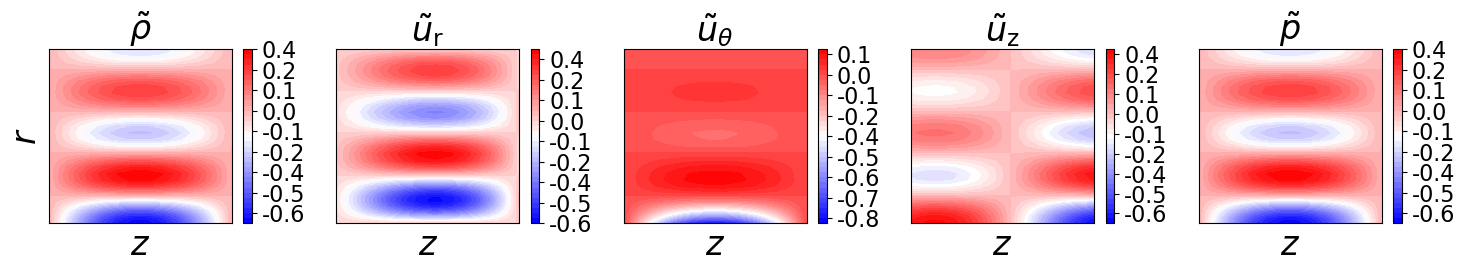

In [28]:
z = pp.data['AxialCoords']
r = pp.data['RadialCoords']
modes_map = cm.bwr
save_filename = 'test'
modesToPlot = slice(0, 8)


imode = 2
mode = pp.eigenfields[imode]
rs = mode.eigenfrequency.real
df = mode.eigenfrequency.imag

fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey=True)
axs = axs.flatten()

titles = [
    r'$\tilde{\rho}$',
    r'$\tilde{u}_{\rm r}$',
    r'$\tilde{u}_{\theta}$',
    r'$\tilde{u}_{\rm z}$',
    r'$\tilde{p}$',
]

fields = [
    mode.eigen_rho,
    mode.eigen_ur,
    mode.eigen_utheta,
    mode.eigen_uz,
    mode.eigen_p,
]


for i, (ax, field, title) in enumerate(zip(axs, fields, titles)):
    cf = ax.contourf(z, r, field, levels=N_levels, cmap=modes_map)
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, format='%.1f')

    # Keep y-label only for first column
    if i == 0:
        ax.set_ylabel(r'$r$')
    else:
        ax.set_ylabel('')

    # Keep x-label only for bottom row
    ax.set_xlabel(r'$z$')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.savefig(
    'pictures/' + save_filename + '_modes_%i_%i_%i.pdf' %
    (pp.nStream, pp.nSpan, imode),
    bbox_inches='tight'
)


In [34]:
with open('analytical_eigenvalues.pickle', 'rb') as f:
    analytical = pickle.load(f)

analytical

array([ 4934.70314645,  8225.60546442,  8897.0924599 , 11066.50551677,
       12002.26721184, 13057.68685745, 14101.82177312, 14622.32800138,
       16112.82009757, 17035.44273414, 17732.17219049, 20143.85420967,
       20466.89373747, 21764.66628178, 23770.68846678, 24969.650227  ,
       26044.00874588, 27742.30205629, 29558.49473308, 30471.48782029,
       31935.19221501, 34200.11503485, 34992.21095463, 36273.95428294])

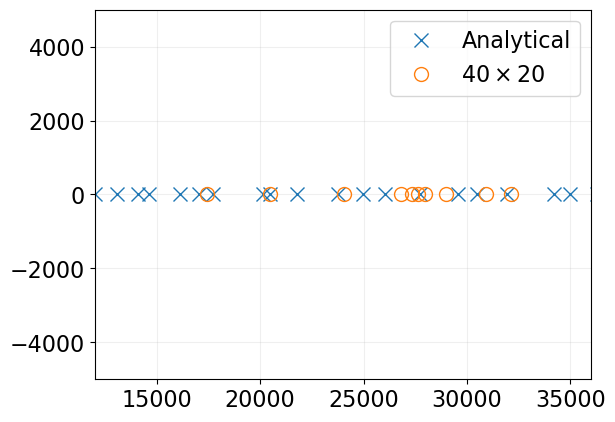

In [36]:
plt.figure()
plt.plot(analytical, analytical*0, 'x', mfc='none', ms=10, label='Analytical')
plt.plot(pp.data['Eigenfrequencies'].real, pp.data['Eigenfrequencies'].imag, 'o', mfc='none', ms=10, label=r'$40 \times 20$')
plt.legend()
plt.grid(alpha=0.2)
plt.xlim([12000, 36000])
plt.ylim([-5000, 5000])
plt.show()